In [1]:
%load_ext autoreload
%autoreload 2

In [12]:
import numpy as np
import trimesh

from meshnet.utils.mesh import Mesh

np.set_printoptions(precision=3, floatmode="fixed", suppress=True)

filepath = "../resources/meshes/Bushing2.msh"

mesh = Mesh.read(filepath)
points = mesh.volume.points

min_coords = np.min(points, axis=0)
max_coords = np.max(points, axis=0)

print("Min coordinates:", min_coords)
print("Max coordinates:", max_coords)

# Sample a point on the surface of the mesh
candidates, _ = trimesh.sample.sample_surface(mesh.surface, count=1)
point = candidates[0]
print("Sampled point on the surface:", point)



Min coordinates: [-0.040 -0.040  0.000]
Max coordinates: [0.040 0.040 0.090]
Sampled point on the surface: [0.008 0.018 0.077]


ld: warning: duplicate -rpath '/Users/bugart/miniconda3/envs/meshnet/lib' ignored
ld: warning: duplicate -rpath '/Users/bugart/miniconda3/envs/meshnet/lib' ignored
ld: warning: duplicate -rpath '/Users/bugart/miniconda3/envs/meshnet/lib' ignored
ld: warning: duplicate -rpath '/Users/bugart/miniconda3/envs/meshnet/lib' ignored


Widget(value='<iframe src="http://localhost:54153/index.html?ui=P_0x31b114a40_0&reconnect=auto" class="pyvista…

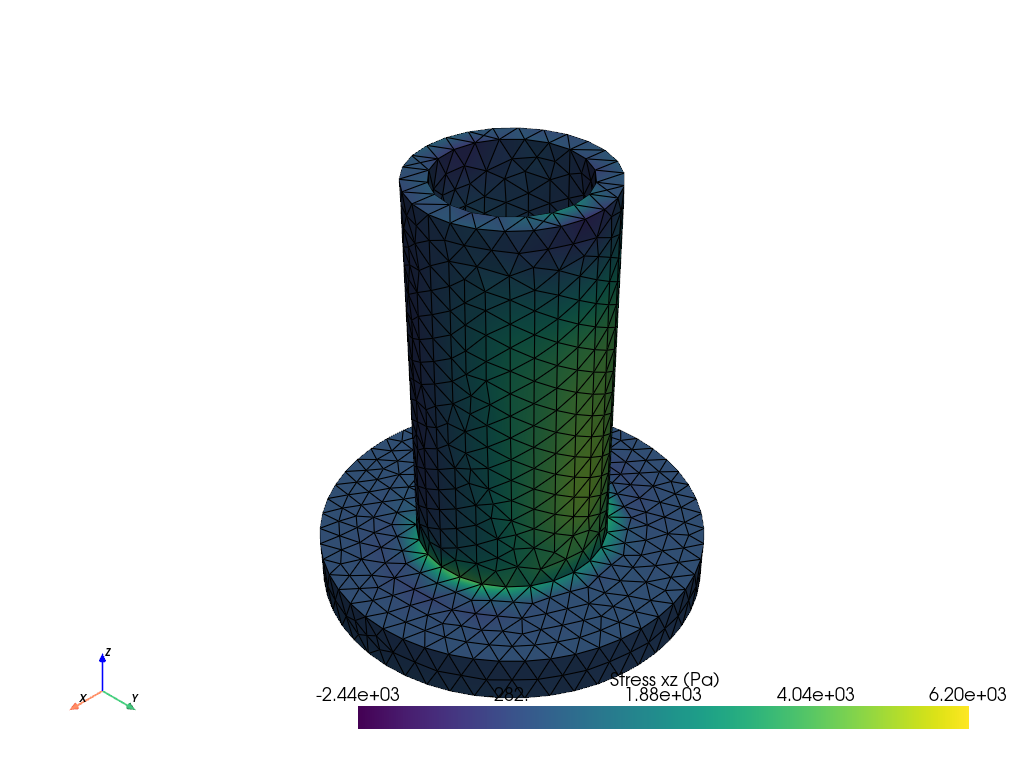

In [14]:
from meshnet.mgn.simulator import Simulator

filepath = "../resources/meshes/Bushing2.msh"

p1 = np.array([0.15, 0.0, 0.025])
f1 = np.array([1.0, 0.0, 0.0])
loads = [(point, f1)]

simulator = Simulator(filepath, order=2, contact_std=0.01)
result = simulator.run(loads)
displacement = result.displacement
stress = simulator.compute_stress(displacement, degree=1)
simulator.plot_stress(stress, component="xz")

In [ ]:
filepath = "../resources/meshes/train/msh/p1/Bushing2_p1.msh"

p1 = np.array([0.15, 0.0, 0.025])
f1 = np.array([1.0, 0.0, 0.0])
loads = [(point, f1)]

simulator = Simulator(filepath, order=2, std=0.01)
displacement = simulator.run(loads)
stress = simulator.compute_stress(displacement, degree=1)
simulator.plot_stress(stress, component="xz")

In [ ]:
stress = simulator.compute_stress(displacement, degree=1)
simulator.plot_stress(stress, component="xz")